In [1]:
## Standard Stuff
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.pyplot as plt
import dask.array as da
import numcodecs
import cftime

## HEALPix Specific
import healpix as hp
import easygems.healpix as egh
import easygems.remap as egr

import intake     # For catalogs
import zarr       # Data Formatting

import warnings
warnings.filterwarnings("ignore")

In [2]:
zoom_select = 6

# shield_cat = intake.open_catalog("/home/tmerlis/hackathon/xsh24_scream_main.yaml")["xsh24_coarse"]
# shield = shield_cat(zoom=zoom_select).to_dask()
# shield = shield.drop_vars("cell")
# shield = shield.pipe(egh.attach_coords)

local_cat = intake.open_catalog("/home/tmerlis/hackathon/hackathon_cat_may14_main.yaml")
print(list(local_cat))

shield = local_cat["xsh24_coarse"](zoom=zoom_select).to_dask()
shield = shield.drop_vars("cell")
shield = shield.pipe(egh.attach_coords)

icon = local_cat["icon_3hp003"](zoom=zoom_select, time_method="mean").to_dask()
icon = icon.pipe(egh.attach_coords)

scream = local_cat["scream_ne120"](zoom=zoom_select).to_dask()
scream = scream.pipe(egh.attach_coords)

cru_cat = intake.open_catalog("/home/cs3554/CERES.yaml")["CERES_Cru23"]
ceres = cru_cat(zoom=zoom_select).to_dask()
ceres = ceres.pipe(egh.attach_coords)

nicam = intake.open_catalog("/scratch/cimes/cs3554/catalog.yaml")["nicam"]
nicam = nicam(zoom=zoom_select)
nicam = nicam.to_dask()
nicam = nicam.pipe(egh.attach_coords)
nicam

['xsh24_coarse', 'xsh24_native', 'xsh21_coarse', 'scream2D_hrly', 'scream_ne120', 'scream_lnd', 'ifs_fesom', 'icon_3hp003']


In [3]:
nicam = intake.open_catalog("/scratch/cimes/cs3554/catalog.yaml")["nicam"]
nicam = nicam(zoom=zoom_select)
nicam = nicam.to_dask()
nicam = nicam.pipe(egh.attach_coords)
nicam

<xarray.Dataset> Size: 19GB
Dimensions:    (time: 2920, cell: 49152, bnds: 2)
Coordinates:
    lev        float64 8B ...
  * time       (time) datetime64[ns] 23kB 2020-03-01T01:30:00 ... 2021-02-28T...
    crs        int64 8B 0
  * cell       (cell) int64 393kB 0 1 2 3 4 5 ... 49147 49148 49149 49150 49151
    lat        (cell) float64 393kB 0.5968 1.194 1.194 ... -1.194 -1.194 -0.5968
    lon        (cell) float64 393kB 45.0 45.7 44.3 45.0 ... 315.7 314.3 315.0
Dimensions without coordinates: bnds
Data variables: (12/31)
    clivi      (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    clt        (time, cell) float64 1GB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    clwvi      (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    hflsd      (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    hfssd      (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    huss       (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    ...         ...
    sftlf      (cell) float32 197kB dask.array<chunksize=(49152,), meta=np.ndarray>
    tas        (time, cell) float64 1GB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    time_bnds  (time, bnds) datetime64[ns] 47kB dask.array<chunksize=(40, 2), meta=np.ndarray>
    ts         (time, cell) float64 1GB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    uas        (time, cell) float64 1GB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    vas        (time, cell) float64 1GB dask.array<chunksize=(40, 49152), meta=np.ndarray>

In [4]:
def calc_atm(F_TOA_up, S, F_surf_dn, F_surf_up):
    S_m = np.ma.masked_less(S, 1e-9)
    F_surf_dn_m = np.ma.masked_less(F_surf_dn, 1e-9)
    R = F_TOA_up / S_m
    T = F_surf_dn / S_m
    a = F_surf_up / F_surf_dn_m
    t = T * (1 - a * R) / (1 - a**2 * T**2)
    r = R - t * a * T
    F_atm = np.where(S_m.mask | F_surf_dn_m.mask, 0, S * r)
    return F_atm

def calc_surf(F_TOA_up, S, F_surf_dn, F_surf_up):
    S_m = np.ma.masked_less(S, 1e-9)
    F_surf_dn_m = np.ma.masked_less(F_surf_dn, 1e-9)
    R = F_TOA_up / S_m
    T = F_surf_dn / S_m
    a = F_surf_up / F_surf_dn_m
    t = T * (1 - a * R) / (1 - a**2 * T**2)
    r = R - t * a * T
    F_surf = np.where(S_m.mask | F_surf_dn_m.mask, 0, S * (a * t**2) / (1 - r * a))
    return F_surf

def do_Crueger23_decomp(ds):

    ds["F_atm"] = xr.apply_ufunc(
        calc_atm, 
        ds.rsut, 
        ds.rsdt, 
        ds.rsds, 
        ds.rsus,
        vectorize=True,
        output_dtypes=[ds.rsdt.dtype],
        dask="allowed"
    )

    ds["F_surf"] = xr.apply_ufunc(
        calc_surf, 
        ds.rsut, 
        ds.rsdt, 
        ds.rsds, 
        ds.rsus,
        vectorize=True,
        output_dtypes=[ds.rsdt.dtype],
        dask="allowed"
    )

    ds["G_atm"] = xr.apply_ufunc(
        calc_atm, 
        ds.rsutcs, 
        ds.rsdt, 
        ds.rsdscs, 
        ds.rsuscs,
        vectorize=True,
        output_dtypes=[ds.rsdt.dtype],
        dask="allowed"
    )

    ds["G_surf"] = xr.apply_ufunc(
        calc_surf, 
        ds.rsutcs, 
        ds.rsdt, 
        ds.rsdscs, 
        ds.rsuscs,
        vectorize=True,
        output_dtypes=[ds.rsdt.dtype],
        dask="allowed"
    )

    ds["gamma"] = ds.F_surf / ds.G_surf # attenuation of surface contribution by clouds
    ds["gamma"] = xr.where(ds.gamma < 1, 1, ds.gamma).fillna(0) # attenuation factor cannot be smaller than 1 because 1 means no attenuation. also if the clear-sky surface contribution is zero it is undefined, so fill as zero.
    ds["F_clr"] = (ds.gamma * ds.G_atm).fillna(0) # assume attenuation of surface by clouds is same as attenuation of atmosphere by clouds (implicitly, assumes that aerosols are below clouds)
    ds["F_clr"] = xr.where(ds.F_clr > ds.F_atm, ds.F_atm, ds.F_clr) # F_clr can't be larger than total atm component
    ds["F_cloud"] = ds.F_atm - ds.F_clr
    ds["F_TOA"] = ds.rsut

    return ds

In [5]:
shield_Cru23 = do_Crueger23_decomp(shield)
shield_Cru23

<xarray.Dataset> Size: 255GB
Dimensions:  (time: 3560, cell: 49152, plev: 31, pfull: 79)
Coordinates:
  * pfull    (pfull) float32 316B 4.514 8.301 12.45 16.74 ... 989.5 994.3 998.3
  * plev     (plev) float32 124B 1.0 2.0 3.0 5.0 7.0 ... 925.0 950.0 975.0 1e+03
  * time     (time) object 28kB 2019-10-20 03:00:00 ... 2021-01-07 00:00:00
    crs      int64 8B 0
  * cell     (cell) int64 393kB 0 1 2 3 4 5 ... 49147 49148 49149 49150 49151
    lat      (cell) float64 393kB 0.5968 1.194 1.194 ... -1.194 -1.194 -0.5968
    lon      (cell) float64 393kB 45.0 45.7 44.3 45.0 ... 315.7 314.3 315.0
Data variables: (12/46)
    clivi    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    clt      (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    clwvi    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hflsd    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hfssd    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hur      (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    ...       ...
    G_atm    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    G_surf   (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    gamma    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_clr    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_cloud  (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_TOA    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>

In [6]:
scream_Cru23 = do_Crueger23_decomp(scream)
scream_Cru23

<xarray.Dataset> Size: 133GB
Dimensions:          (time: 3168, cell: 49152, level: 25)
Coordinates:
  * time             (time) object 25kB 2019-08-01 03:00:00 ... 2020-09-01 00...
    lev              (level) int64 200B dask.array<chunksize=(4,), meta=np.ndarray>
    crs              int64 8B 0
  * cell             (cell) int64 393kB 0 1 2 3 4 ... 49148 49149 49150 49151
    lat              (cell) float64 393kB 0.5968 1.194 1.194 ... -1.194 -0.5968
    lon              (cell) float64 393kB 45.0 45.7 44.3 ... 315.7 314.3 315.0
Dimensions without coordinates: level
Data variables: (12/45)
    clt              (time, cell) float32 623MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hflsd            (time, cell) float32 623MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hfssd            (time, cell) float32 623MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    huss             (time, cell) float32 623MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    lwcre            (time, cell) float32 623MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    pr               (time, cell) float32 623MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    ...               ...
    G_atm            (time, cell) float32 623MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    G_surf           (time, cell) float32 623MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    gamma            (time, cell) float32 623MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_clr            (time, cell) float32 623MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_cloud          (time, cell) float32 623MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_TOA            (time, cell) float32 623MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
Attributes: (12/22)
    Conventions:                  CF-1.8
    atm_initial_conditions_file:  /lustre/orion/cli115/world-shared/e3sm/inpu...
    averaging_frequency:          3
    averaging_frequency_units:    nhours
    averaging_type:               AVERAGE
    case:                         cess-control.ne1024pg2_ne1024pg2.F2010-SCRE...
    ...                           ...
    product:                      model-output
    realm:                        atmos
    run_t0:                       2019-08-01-00000
    source:                       E3SM Atmosphere Model (EAMxx)
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel

In [7]:
icon_Cru23 = do_Crueger23_decomp(icon)
icon_Cru23

<xarray.Dataset> Size: 25GB
Dimensions:        (time: 425, cell: 49152, pressure: 30, soil_level: 5,
                    pressure_rva: 3)
Coordinates:
  * pressure       (pressure) int64 240B 5 10 20 50 ... 92500 95000 97500 100000
  * pressure_rva   (pressure_rva) int64 24B 16 18 23
  * soil_level     (soil_level) int64 40B 0 0 0 2 6
  * time           (time) datetime64[ns] 3kB 2020-01-02 ... 2021-03-01
    crs            int64 8B 0
  * cell           (cell) int64 393kB 0 1 2 3 4 ... 49148 49149 49150 49151
    lat            (cell) float64 393kB 0.5968 1.194 1.194 ... -1.194 -0.5968
    lon            (cell) float64 393kB 45.0 45.7 44.3 ... 315.7 314.3 315.0
Data variables: (12/66)
    clivi          (time, cell) float32 84MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    clt            (time, cell) float32 84MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    clwvi          (time, cell) float32 84MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    egpvi          (time, cell) float32 84MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    einvi          (time, cell) float32 84MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    ekhvi          (time, cell) float32 84MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    ...             ...
    G_atm          (time, cell) float32 84MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    G_surf         (time, cell) float32 84MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    gamma          (time, cell) float32 84MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_clr          (time, cell) float32 84MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_cloud        (time, cell) float32 84MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_TOA          (time, cell) float32 84MB dask.array<chunksize=(24, 49152), meta=np.ndarray>

In [11]:
nicam_Cru23 = do_Crueger23_decomp(nicam)
nicam_Cru23

<xarray.Dataset> Size: 24GB
Dimensions:    (time: 2920, cell: 49152, bnds: 2)
Coordinates:
    lev        float64 8B ...
  * time       (time) datetime64[ns] 23kB 2020-03-01T01:30:00 ... 2021-02-28T...
    crs        int64 8B 0
  * cell       (cell) int64 393kB 0 1 2 3 4 5 ... 49147 49148 49149 49150 49151
    lat        (cell) float64 393kB 0.5968 1.194 1.194 ... -1.194 -1.194 -0.5968
    lon        (cell) float64 393kB 45.0 45.7 44.3 45.0 ... 315.7 314.3 315.0
Dimensions without coordinates: bnds
Data variables: (12/39)
    clivi      (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    clt        (time, cell) float64 1GB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    clwvi      (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    hflsd      (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    hfssd      (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    huss       (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    ...         ...
    G_atm      (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    G_surf     (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    gamma      (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    F_clr      (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    F_cloud    (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>
    F_TOA      (time, cell) float32 574MB dask.array<chunksize=(40, 49152), meta=np.ndarray>

In [12]:
def worldmap(var, ax=None, **kwargs):
    if ax == None:
        projection = ccrs.Robinson(central_longitude=-135.5808361)
        fig, ax = plt.subplots(
            figsize=(8, 4), subplot_kw={"projection": projection}, constrained_layout=True
        )
    ax.set_global()

    hpshow = egh.healpix_show(var, ax=ax, **kwargs)
    cbar = plt.colorbar(hpshow, ax=ax, orientation='vertical', 
                    pad=0.05, shrink=0.8)
    # fails when cartopy tries to download 
    ax.add_feature(cf.COASTLINE, color="w", linewidth=0.8)
    # ax.add_feature(cf.BORDERS, linewidth=0.4)

In [13]:
# projection = ccrs.Robinson(central_longitude=-135.5808361)
# fig, axes = plt.subplots(3,3,figsize=(10,5),constrained_layout=True,subplot_kw={"projection": projection})
# v = ["F_surf","F_clr","F_cloud"]
# vmax = [60, 60, 100]

# for i in range(3):
#     ax = axes[i,0]
#     worldmap(shield_Cru23_clim[v[i]].mean(dim="month"), ax=ax, cmap="inferno", vmax=vmax[i])
#     ax.set_title(v[i]+" XSHiELD")

#     ax = axes[i,1]
#     worldmap(ceres_clim[v[i]].mean(dim="month"), ax=ax, cmap="inferno", vmax=vmax[i])
#     ax.set_title(v[i]+" CERES")

#     ax = axes[i,2]
#     worldmap((shield_Cru23_clim[v[i]] - ceres_clim[v[i]]).mean(dim="month"), ax=ax, 
#              cmap="bwr", vmin=-vmax[i]/2, vmax=vmax[i]/2)
#     ax.set_title(v[i]+" XSHiELD -- CERES")

# # plt.savefig("Cru23_maps.png",dpi=200,bbox_inches="tight")
# plt.show()

In [14]:
shield_Cru23_clim = shield_Cru23.groupby("time.month").mean("time")[["F_surf","F_clr","F_cloud"]].load()
icon_Cru23_clim = icon_Cru23.groupby("time.month").mean("time").load()
nicam_Cru23_clim = nicam_Cru23.groupby("time.month").mean("time").load()
scream_Cru23_clim = scream_Cru23.groupby("time.month").mean("time")[["F_surf","F_clr","F_cloud"]].load()

ceres_clim = ceres.groupby("time.month").mean("time")[["F_surf","F_clr","F_cloud"]].load()

# ceres_clim

In [15]:
model_dict = {
    "xsh24_coarse":shield_Cru23_clim,
    "icon_3hp003":icon_Cru23_clim,
    "nicam_gl11":nicam_Cru23_clim,
    "scream_ne120":scream_Cru23_clim,
}
ncol = len(model_dict.keys())+1

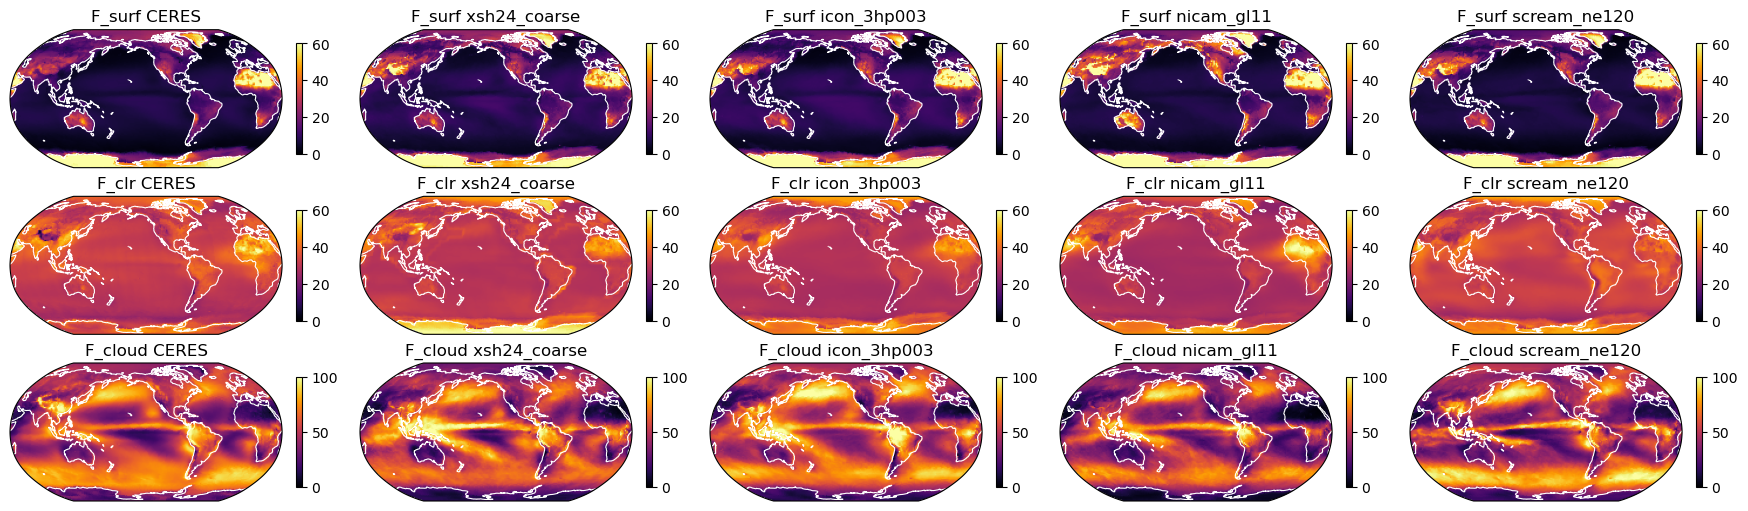

In [16]:
projection = ccrs.Robinson(central_longitude=-135.5808361)
fig, axes = plt.subplots(3,ncol,figsize=(3.5*ncol,5),constrained_layout=True,subplot_kw={"projection": projection})
v = ["F_surf","F_clr","F_cloud"]
vmax = [60, 60, 100]


for i in range(3):
    ax = axes[i,0]
    worldmap(ceres_clim[v[i]].mean(dim="month"), ax=ax, cmap="inferno", vmin=0, vmax=vmax[i])
    ax.set_title(v[i]+" CERES")
    
    for j,model_name in enumerate(model_dict.keys()):
        ax = axes[i,j+1]
        worldmap(model_dict[model_name][v[i]].mean(dim="month"), ax=ax, 
                 cmap="inferno", vmin=0, vmax=vmax[i])
        ax.set_title(v[i]+" "+model_name)

plt.savefig("Cru23_maps.png",dpi=200,bbox_inches="tight")
plt.show()

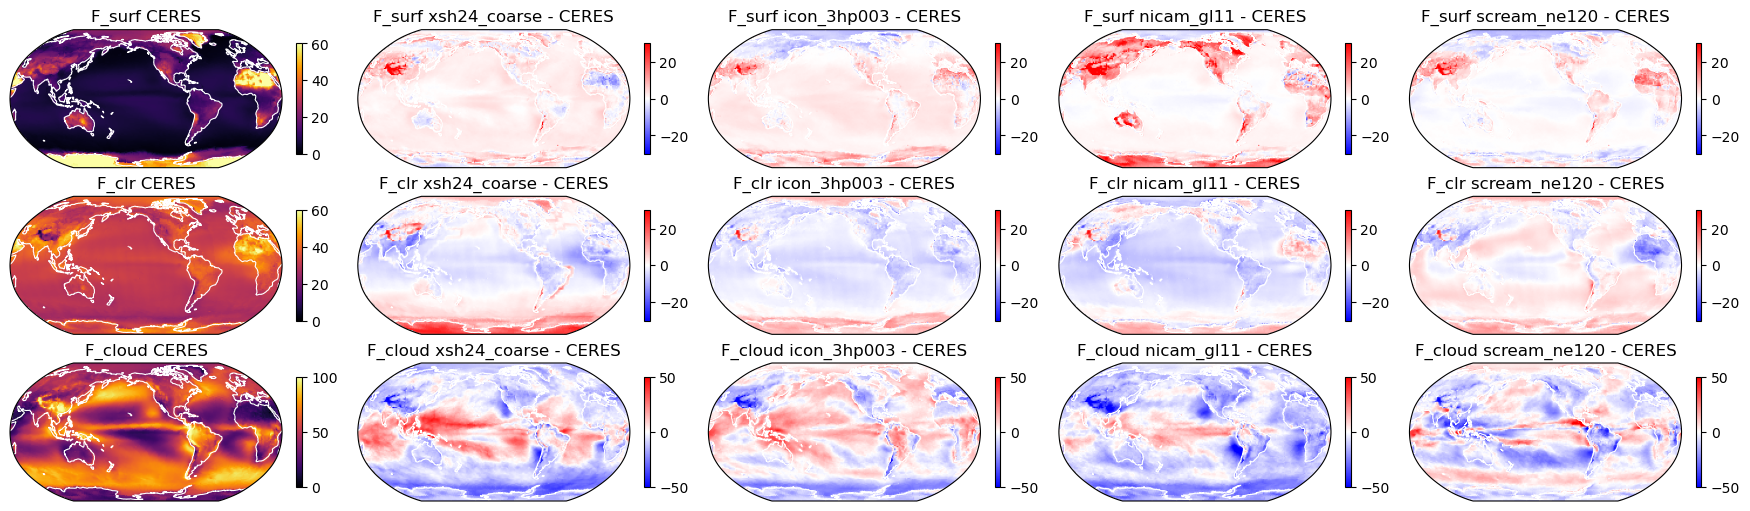

In [17]:
projection = ccrs.Robinson(central_longitude=-135.5808361)
fig, axes = plt.subplots(3,ncol,figsize=(3.5*ncol,5),constrained_layout=True,subplot_kw={"projection": projection})
v = ["F_surf","F_clr","F_cloud"]
vmax = [60, 60, 100]


for i in range(3):
    ax = axes[i,0]
    worldmap(ceres_clim[v[i]].mean(dim="month"), ax=ax, cmap="inferno", vmin=0, vmax=vmax[i])
    ax.set_title(v[i]+" CERES")
    
    for j,model_name in enumerate(model_dict.keys()):
        ax = axes[i,j+1]
        worldmap((model_dict[model_name][v[i]] - ceres_clim[v[i]]).mean(dim="month"), ax=ax, 
                 cmap="bwr", vmin=-vmax[i]/2, vmax=vmax[i]/2)
        ax.set_title(v[i]+" "+model_name+" - CERES")

plt.savefig("Cru23_diff_maps.png",dpi=200,bbox_inches="tight")
plt.show()